In [30]:
import json
from urllib.request import Request, urlopen

resourceId = "M920141"

hdr = {
    "User-Agent": "Mozilla/5.0",
    "Accept": "application/json"
}

url = f"https://tablebuilder.singstat.gov.sg/api/table/tabledata/{resourceId}"

request = Request(url, headers=hdr)

with urlopen(request) as response:
    data = json.load(response)

#print(data)

In [31]:
import pandas as pd

rows = data["Data"]["row"]

records = []

for row in rows:
    category = row["rowText"]      # Total, Male, Female

    for item in row["columns"]:
        records.append({
            "Category": category,
            "Year": int(item["key"]),
            "Value": float(item["value"])
        })

df = pd.DataFrame(records)

print(df.tail())

   Category  Year  Value
43   Female  2020  879.3
44   Female  2021  913.0
45   Female  2022  940.8
46   Female  2023  953.8
47   Female  2024  965.3


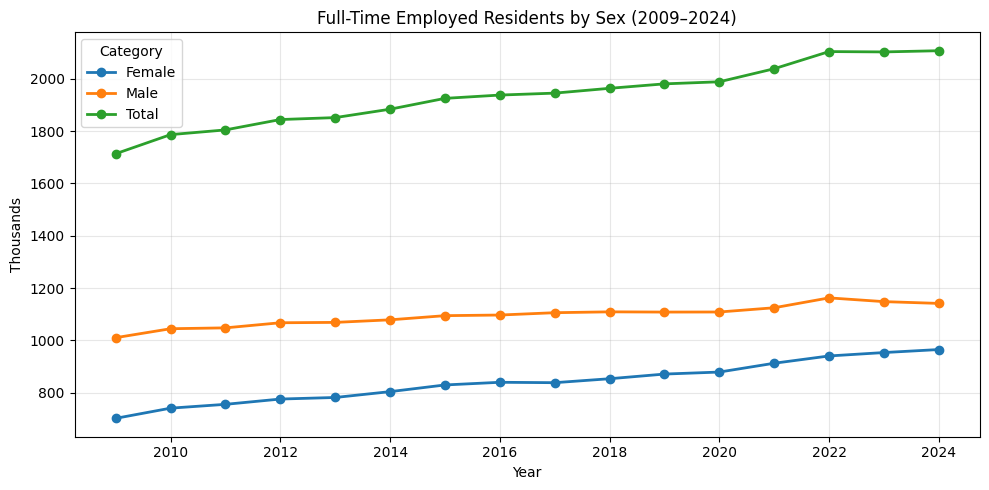

In [32]:
import matplotlib.pyplot as plt

# Convert long -> wide
plot_df = df.pivot(
    index="Year",
    columns="Category",
    values="Value"
)

# Plot
ax = plot_df.plot(
    figsize=(10, 5),
    marker="o",
    linewidth=2
)

ax.set_title("Full-Time Employed Residents by Sex (2009–2024)")
ax.set_xlabel("Year")
ax.set_ylabel("Thousands")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()